# Hotel Bookings Analysis — Cancellations, Revenue & Channel Performance

**Author:** Himanshu Kumar | [LinkedIn](https://www.linkedin.com/in/himanshu-kumar-2025h) | [GitHub](https://github.com/HimanshuYadav2024)

## Business Context
A multi-city hotel booking platform wants to understand **why bookings are being lost, which channels and room types drive the most cancellations, and how revenue behaves across channels, time, and customer behavior (coupons, payment methods).** This analysis works through 30,000 bookings across 10 US cities (Apr 2024 – Apr 2025) to answer four business questions:

1. Where in the booking funnel is the platform losing the most value (cancellations)?
2. Which booking channel × room type combinations are the riskiest?
3. Is the coupon program actually driving higher booking value, or just discounting sales that would have happened anyway?
4. What should the business prioritize first?

## Dataset
| | |
|---|---|
| Rows | 30,000 bookings |
| Columns | 24 |
| Time span | April 2024 – April 2025 |
| Cities | 10 (US) |
| Source file | `Hotel_bookings_final.xlsx` |

## Tools
`pandas` · `numpy` · `matplotlib` · `seaborn` · `scipy.stats`


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('default')
sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', '{:.2f}'.format)

PALETTE = ["#1E5AA0", "#2E9E8F", "#E0A72E", "#C0504D"]
sns.set_palette(PALETTE)

## 2. Load Data

> Place `Hotel_bookings_final.xlsx` in the same folder as this notebook before running.

In [2]:
df = pd.read_excel("Hotel_bookings_final.xlsx")
df.shape

(30000, 24)

## 3. Data Overview

In [3]:
df.head()

,customer_id,property_id,city,star_rating,booking_date,check_in_date,check_out_date,room_type,num_rooms_booked,stay_type,...,selling_price,payment_method,refund_status,refund_amount,channel_of_booking,booking_status,travel_date,cashback,coupon_redeem,Coupon USed?
0,492,3,San Francisco,4,2024-04-01,2024-05-24,2024-05-26,Standard,1,Leisure,...,25342,PayPal,Yes,369.65,Web,Confirmed,2024-03-04,5.37,0.00,No
1,180,3,Dallas,3,2024-04-01,2024-05-10,2024-05-17,Deluxe,1,Leisure,...,8033,Bank Transfer,Yes,492.51,Web,Confirmed,2024-07-19,7.16,0.00,No
2,50,5,Dallas,3,2024-04-01,2024-05-31,2024-06-05,Deluxe,1,Business,...,29715,Debit Card,Yes,0.00,iOS,Confirmed,2024-03-22,0.00,0.00,No
3,294,3,Orlando,4,2024-04-01,2024-04-18,2024-04-24,Deluxe,3,Leisure,...,44592,Bank Transfer,Yes,545.54,Android,Confirmed,2024-11-24,7.93,24.50,Yes
4,40,5,Seattle,5,2024-04-01,NaT,NaT,Deluxe,1,Leisure,...,15873,Debit Card,Yes,211.37,Web,Cancelled,2024-03-02,0.00,0.00,No


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         30000 non-null  int64         
 1   property_id         30000 non-null  int64         
 2   city                30000 non-null  str           
 3   star_rating         30000 non-null  int64         
 4   booking_date        30000 non-null  datetime64[us]
 5   check_in_date       24532 non-null  datetime64[us]
 6   check_out_date      24532 non-null  datetime64[us]
 7   room_type           30000 non-null  str           
 8   num_rooms_booked    30000 non-null  int64         
 9   stay_type           30000 non-null  str           
 10  booking_channel     30000 non-null  str           
 11  booking_value       30000 non-null  float64       
 12  costprice           30000 non-null  int64         
 13  markup              30000 non-null  int64         
 14  s

In [5]:
df.describe()

,customer_id,property_id,star_rating,booking_date,check_in_date,check_out_date,num_rooms_booked,booking_value,costprice,markup,selling_price,refund_amount,travel_date,cashback,coupon_redeem
count,30000.00,30000.00,30000.00,30000,24532,24532,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000,30000.00,30000.00
mean,249.72,3.78,3.60,2024-10-14 12:00:02.880000,2024-11-14 03:36:32.401761,2024-11-18 03:46:24.086091,1.35,25080.53,22541.49,6963.32,29504.82,320.94,2024-07-24 03:53:11.040000,3.83,4.13
min,1.00,1.00,2.00,2024-04-01 00:00:00,2024-04-02 00:00:00,2024-04-04 00:00:00,1.00,1279.77,3822.00,1181.00,5003.00,0.00,2024-03-02 00:00:00,0.00,-3.53
25%,123.00,1.00,3.00,2024-07-08 00:00:00,2024-08-08 00:00:00,2024-08-12 00:00:00,1.00,15922.71,15088.75,4661.75,19750.50,0.00,2024-05-28 00:00:00,0.00,0.00
50%,248.00,3.00,4.00,2024-10-14 12:00:00,2024-11-16 00:00:00,2024-11-19 12:00:00,1.00,24736.15,22731.00,7021.50,29752.50,221.14,2024-07-23 00:00:00,1.03,0.00
75%,376.00,5.00,4.00,2025-01-21 00:00:00,2025-02-20 00:00:00,2025-02-25 00:00:00,2.00,33570.00,30427.00,9399.00,39826.00,594.62,2024-09-08 00:00:00,7.38,0.00
max,499.00,7.00,5.00,2025-04-30 00:00:00,2025-06-28 00:00:00,2025-07-03 00:00:00,3.00,67764.46,38200.00,11800.00,50000.00,1462.73,2025-01-29 00:00:00,21.27,89.64
std,145.48,2.08,0.86,NaN,NaN,NaN,0.57,11587.37,9259.52,2860.11,12119.63,339.64,NaN,4.78,10.85


## 4. Data Cleaning & Quality Check

Two things need fixing before analysis:
- The column `Coupon USed?` has an inconsistent name and casing — rename it to `coupon_used` for consistency.
- `check_in_date` / `check_out_date` are missing for 5,468 rows. Before treating this as a data quality defect, it's worth checking *whether* the missing values are random or structural.

In [6]:
df = df.rename(columns={"Coupon USed?": "coupon_used"})

missing = df.isnull().sum()
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ["Column", "Missing Values"]
missing_df["% of Total"] = (missing_df["Missing Values"] / len(df) * 100).round(2)
missing_df

,Column,Missing Values,% of Total
0,check_in_date,5468,18.23
1,check_out_date,5468,18.23


In [7]:
# Are the missing check-in/check-out dates random, or tied to a specific booking outcome?
df[df['check_in_date'].isnull()]['booking_status'].value_counts()

booking_status
Cancelled    5045
Failed        423
Name: count, dtype: int64

**Insight:** All 5,468 missing `check_in_date` / `check_out_date` values belong to **Cancelled (5,045)** or **Failed (423)** bookings — together they account for exactly the missing count. This isn't a data entry error; a booking that never completed simply never received a confirmed stay date. **No imputation is needed** — the missingness itself is informative and should be preserved as a signal, not filled in.

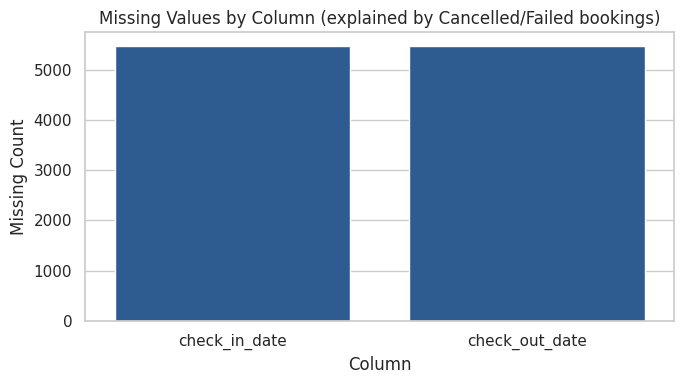

In [8]:
fig, ax = plt.subplots(figsize=(7,4))
sns.barplot(x=missing_df['Column'], y=missing_df['Missing Values'], ax=ax)
ax.set_title("Missing Values by Column (explained by Cancelled/Failed bookings)")
ax.set_ylabel("Missing Count")
plt.tight_layout()
plt.show()

## 5. Booking Status Distribution

In [9]:
booking_status = df['booking_status'].value_counts()
booking_status

booking_status
Confirmed    21672
Cancelled     6070
Failed        2258
Name: count, dtype: int64

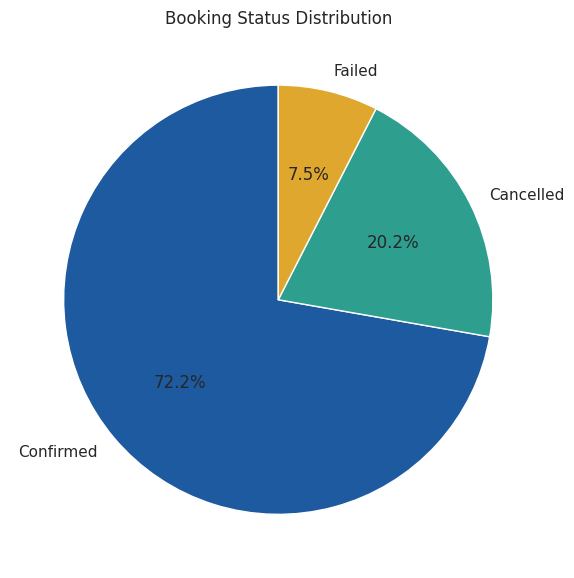

In [10]:
fig, ax = plt.subplots(figsize=(6,6))
ax.pie(booking_status, labels=booking_status.index, autopct='%1.1f%%',
       colors=PALETTE, startangle=90, wedgeprops={'edgecolor':'white'})
ax.set_title("Booking Status Distribution")
plt.tight_layout()
plt.show()

**Insight:** ~20% of all bookings end in cancellation and another ~7.5% fail outright — meaning **over a quarter of demand never converts into revenue.** This is the single biggest value-leakage point in the funnel and the natural place to focus the rest of this analysis.

## 6. Cancellation Rate Analysis

Cancellation flag created once and reused throughout.

In [11]:
df['is_cancelled'] = np.where(df['booking_status'] == 'Cancelled', 1, 0)

### 6.1 By Booking Channel

In [12]:
channel_cancel = (df.groupby('booking_channel')['is_cancelled'].mean() * 100).sort_values(ascending=False)
channel_cancel

booking_channel
Travel Agent   27.93
Mobile App     21.56
Web            17.64
Name: is_cancelled, dtype: float64

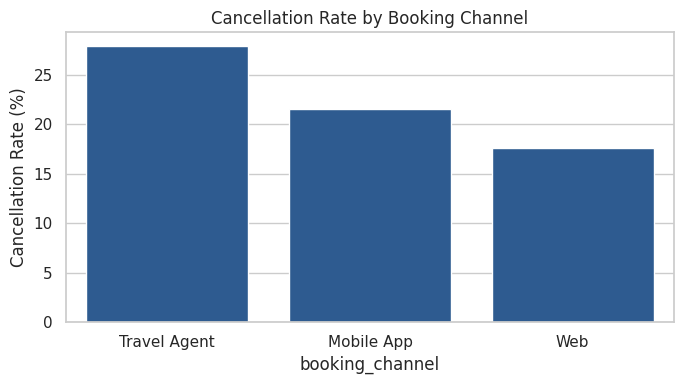

In [13]:
fig, ax = plt.subplots(figsize=(7,4))
sns.barplot(x=channel_cancel.index, y=channel_cancel.values, ax=ax)
ax.set_title("Cancellation Rate by Booking Channel")
ax.set_ylabel("Cancellation Rate (%)")
plt.tight_layout()
plt.show()

**Insight:** Travel Agent bookings cancel at **~28%**, roughly 1.6x the rate of Web bookings (**~17.6%**). Travel-agent-sourced demand is the least reliable — likely because agents book speculatively across multiple properties/hotels on behalf of a client and cancel the ones not chosen.

### 6.2 By Room Type

In [14]:
room_cancel = (df.groupby('room_type')['is_cancelled'].mean() * 100).sort_values(ascending=False)
room_cancel

room_type
Standard   23.30
Suite      17.98
Deluxe     16.02
Name: is_cancelled, dtype: float64

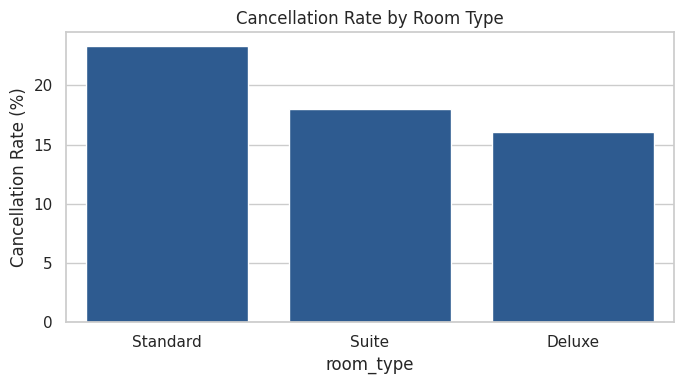

In [15]:
fig, ax = plt.subplots(figsize=(7,4))
sns.barplot(x=room_cancel.index, y=room_cancel.values, ax=ax)
ax.set_title("Cancellation Rate by Room Type")
ax.set_ylabel("Cancellation Rate (%)")
plt.tight_layout()
plt.show()

**Insight:** Standard rooms cancel at **~23%** vs **~16%** for Deluxe. Customers booking the lowest tier room appear more price-sensitive and more likely to keep shopping around after booking — a classic "cheap, easy to abandon" pattern.

### 6.3 Where the two intersect (the highest-risk segment)

Channel and room type on their own only tell half the story — the real risk shows up where they combine.

In [16]:
risk_matrix = pd.pivot_table(df, index='booking_channel', columns='room_type',
                              values='is_cancelled', aggfunc='mean') * 100
risk_matrix = risk_matrix.round(2)
risk_matrix

room_type,Deluxe,Standard,Suite
booking_channel,,,
Mobile App,17.65,24.05,21.45
Travel Agent,24.69,31.06,22.30
Web,12.96,21.19,14.23


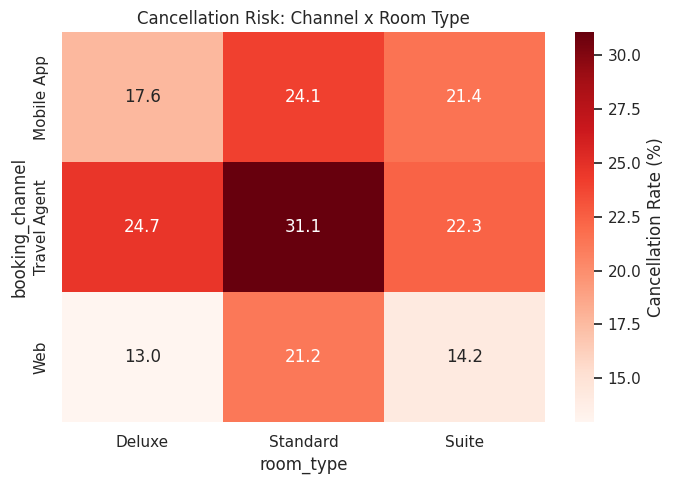

In [17]:
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(risk_matrix, annot=True, fmt=".1f", cmap="Reds", ax=ax, cbar_kws={'label': 'Cancellation Rate (%)'})
ax.set_title("Cancellation Risk: Channel x Room Type")
plt.tight_layout()
plt.show()

**Insight — the key finding of this analysis:** **Travel Agent + Standard room** bookings cancel at **31%**, the highest of any combination — nearly **2.4x** the rate of the safest combination, **Web + Deluxe (13%)**. This single segment should be the first target for intervention (e.g. a stricter cancellation window or partial deposit for agent-booked Standard rooms), rather than applying a blanket cancellation policy across all channels.

### 6.4 Sanity check: does city matter?

In [18]:
city_cancel = (df.groupby('city')['is_cancelled'].mean() * 100).sort_values(ascending=False)
city_cancel

city
Los Angeles     20.92
Chicago         20.53
Orlando         20.50
New York        20.31
Miami           20.31
Las Vegas       20.26
Boston          20.19
Dallas          20.00
San Francisco   19.89
Seattle         19.39
Name: is_cancelled, dtype: float64

**Insight:** Cancellation rate by city is essentially flat (**19.4%–20.9%**, a <1.5pt spread) — geography is **not** a meaningful driver here. This rules out "some cities have unreliable customers" as an explanation and reinforces that the channel/room-type pattern above is the real signal, not noise.

## 7. Revenue & Profit Analysis

`selling_price = costprice + markup` holds exactly for all 30,000 rows, so profit is computed directly as the markup captured.

In [19]:
df['profit'] = df['selling_price'] - df['costprice']
df['profit'].describe()

count   30000.00
mean     6963.32
std      2860.11
min      1181.00
25%      4661.75
50%      7021.50
75%      9399.00
max     11800.00
Name: profit, dtype: float64

In [20]:
channel_value = df.groupby('booking_channel')['booking_value'].mean().sort_values(ascending=False)
profit_channel = df.groupby('booking_channel')['profit'].mean().sort_values(ascending=False)
pd.DataFrame({'Avg Booking Value': channel_value, 'Avg Profit': profit_channel})

,Avg Booking Value,Avg Profit
booking_channel,,
Mobile App,21351.29,6943.90
Travel Agent,24453.97,6931.74
Web,28190.84,6985.17


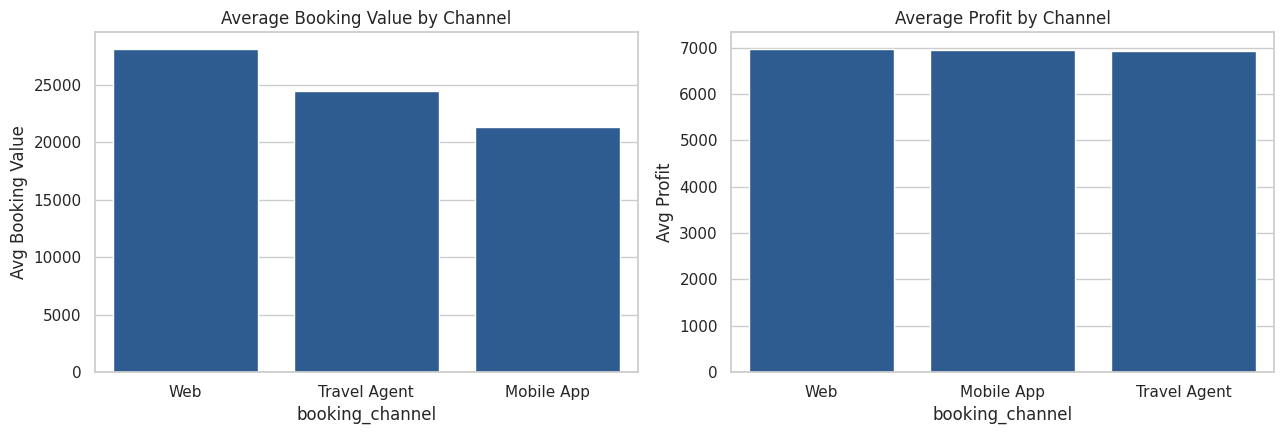

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
sns.barplot(x=channel_value.index, y=channel_value.values, ax=axes[0])
axes[0].set_title("Average Booking Value by Channel")
axes[0].set_ylabel("Avg Booking Value")

sns.barplot(x=profit_channel.index, y=profit_channel.values, ax=axes[1])
axes[1].set_title("Average Profit by Channel")
axes[1].set_ylabel("Avg Profit")
plt.tight_layout()
plt.show()

**Insight:** Web bookings lead on both average booking value (**₹28,191**) and average profit (**₹6,985**) — and, from Section 6.1, also cancel the *least*. Web is the highest-quality channel on every dimension measured here, which makes it the clearest candidate for further investment (marketing spend, UX improvements) relative to Travel Agent, which is both lower-value and higher-risk.

## 8. Monthly Booking Trend

In [22]:
df['booking_date'] = pd.to_datetime(df['booking_date'])
df['month'] = df['booking_date'].dt.month_name()

month_order = ['January','February','March','April','May','June','July',
               'August','September','October','November','December']

monthly_revenue = df.groupby('month')['booking_value'].mean().reindex(month_order)
monthly_revenue

month
January     23424.24
February    27806.45
March       27316.32
April       25116.49
May         23197.15
June        24202.79
July        25501.59
August      26064.74
September   24635.11
October     24880.62
November    25753.25
December    23276.99
Name: booking_value, dtype: float64

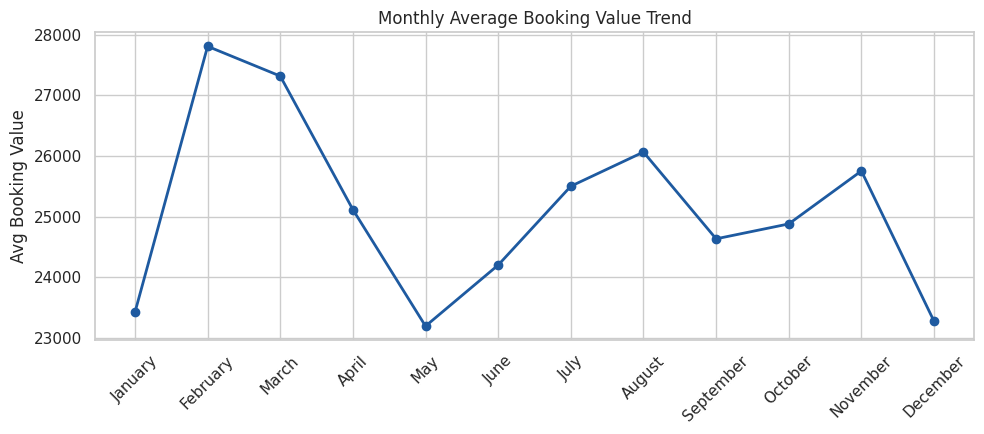

In [23]:
fig, ax = plt.subplots(figsize=(10,4.5))
ax.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color=PALETTE[0], linewidth=2)
ax.set_title("Monthly Average Booking Value Trend")
ax.set_ylabel("Avg Booking Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** February and March post the highest average booking values (**₹27.3k–₹27.8k**), while May sits lowest (**₹23.2k**) — a swing of roughly 20%. This lines up with pre-summer travel planning and is useful for timing promotional campaigns: discount pressure is less necessary in Feb/Mar demand is already strong, and more useful in the May dip to stimulate bookings.

## 9. Coupon Usage Impact

The obvious question isn't just "what's the average booking value by coupon usage" — it's **whether that difference is real or just noise.** A two-sample t-test settles that.

In [24]:
coupon_avg = df.groupby('coupon_used')['booking_value'].mean()
coupon_avg

coupon_used
No    25167.90
Yes   24744.65
Name: booking_value, dtype: float64

In [25]:
with_coupon = df[df['coupon_used'] == 'Yes']['booking_value'].dropna()
without_coupon = df[df['coupon_used'] == 'No']['booking_value'].dropna()

t_stat, p_value = stats.ttest_ind(with_coupon, without_coupon, equal_var=False)
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")

t-statistic: -2.677
p-value: 0.0074


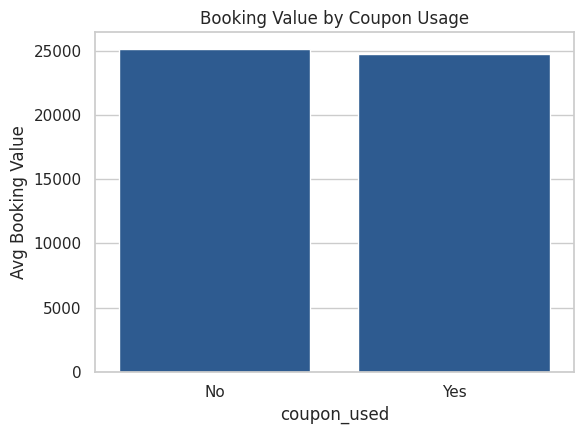

In [26]:
fig, ax = plt.subplots(figsize=(6,4.5))
sns.barplot(x=coupon_avg.index, y=coupon_avg.values, ax=ax)
ax.set_title("Booking Value by Coupon Usage")
ax.set_ylabel("Avg Booking Value")
plt.tight_layout()
plt.show()

**Insight:** The gap looks small (₹25,168 without a coupon vs ₹24,745 with one) but the t-test confirms it's statistically significant (**p = 0.007**, not due to chance) — and the direction is the opposite of what a coupon program is supposed to do. **Coupon users spend slightly less on average, not more.** This suggests the coupon program is mostly subsidizing bookings that would have happened anyway (discounting existing demand) rather than driving incremental higher-value bookings, and is worth revisiting from an ROI standpoint.

## 10. Payment Method Analysis

In [27]:
payment_analysis = df['payment_method'].value_counts()
payment_analysis

payment_method
Debit Card       7603
PayPal           7584
Credit Card      7492
Bank Transfer    7321
Name: count, dtype: int64

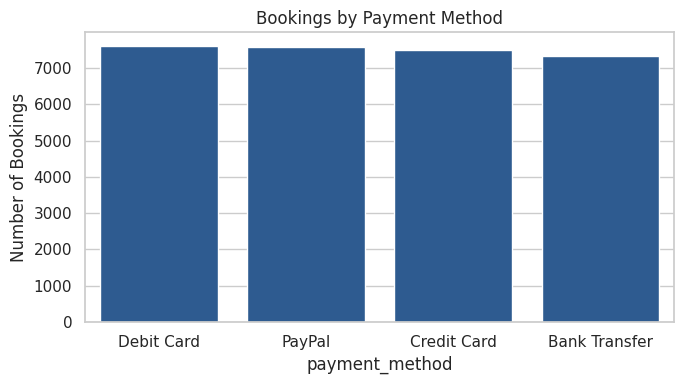

In [28]:
fig, ax = plt.subplots(figsize=(7,4))
sns.barplot(x=payment_analysis.index, y=payment_analysis.values, ax=ax)
ax.set_title("Bookings by Payment Method")
ax.set_ylabel("Number of Bookings")
plt.tight_layout()
plt.show()

**Insight:** Payment method is close to evenly split across Debit Card, PayPal, Credit Card and Bank Transfer (all within a ~4% band of each other). There's no dominant or neglected payment method — this isn't a lever worth prioritizing compared to the channel and room-type findings above.

## 11. Correlation Heatmap

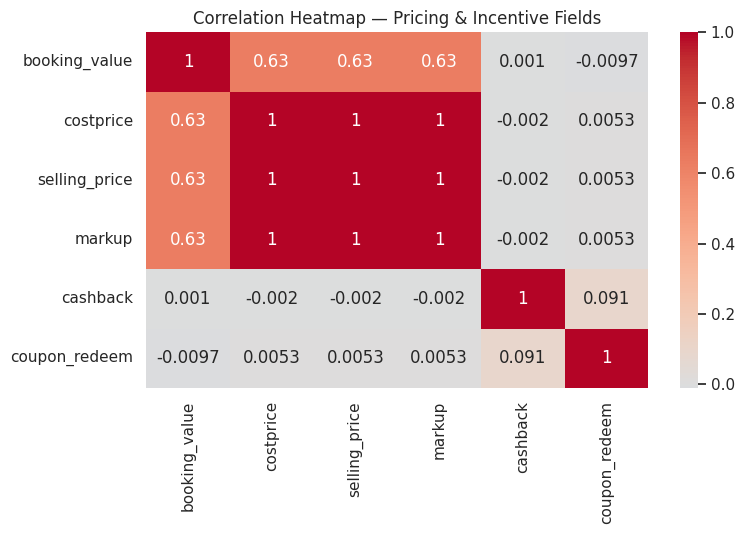

In [29]:
numeric_cols = ['booking_value', 'costprice', 'selling_price', 'markup', 'cashback', 'coupon_redeem']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8,5.5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title("Correlation Heatmap — Pricing & Incentive Fields")
plt.tight_layout()
plt.show()

**Insight:** `costprice`, `selling_price`, and `markup` are perfectly correlated (r = 1.0) by construction, since `selling_price = costprice + markup` — this confirms the pricing fields are internally consistent rather than independently entered (a good data-quality sign). `booking_value` correlates moderately (r ≈ 0.63) with those fields but is a distinct figure, likely the originally quoted price before final adjustments. `cashback` and `coupon_redeem` show negligible correlation with pricing, confirming incentives are applied fairly independently of order size.

## 12. Executive Summary & Recommendations

In [1]:
total_bookings = len(df)
confirmed = (df['booking_status'] == 'Confirmed').sum()
cancelled = (df['booking_status'] == 'Cancelled').sum()
failed = (df['booking_status'] == 'Failed').sum()
cancel_rate = round(cancelled / total_bookings * 100, 2)
avg_booking_value = round(df['booking_value'].mean(), 2)
avg_profit = round(df['profit'].mean(), 2)

kpis = pd.DataFrame({
    'Metric': ['Total Bookings', 'Confirmed', 'Cancelled', 'Failed',
               'Cancellation Rate (%)', 'Avg Booking Value', 'Avg Profit / Booking'],
    'Value': [total_bookings, confirmed, cancelled, failed,
              cancel_rate, avg_booking_value, avg_profit]
})
kpis

NameError: name 'df' is not defined

### Key Findings
1. **Over a quarter of demand doesn't convert** — 20.2% cancellation + 7.5% failure rate.
2. **Travel Agent + Standard room is the highest-risk segment** — 31% cancellation rate, 2.4x the safest combination (Web + Deluxe, 13%).
3. **Web is the best-performing channel across the board** — highest booking value, highest profit, lowest cancellation rate.
4. **The coupon program isn't lifting order value** — coupon users spend statistically significantly *less*, not more (p = 0.007), suggesting it's subsidizing existing demand rather than growing it.
5. **February–March is peak demand; May is the trough** — a ~20% swing in average booking value, useful for promo timing.
6. **City and payment method are not meaningful drivers** of either cancellation or revenue — ruled out so effort isn't wasted here.

### Recommendations
- **Tighten cancellation policy specifically for Travel Agent + Standard room bookings** (e.g. partial non-refundable deposit) rather than a blanket policy — this is where the leakage is concentrated.
- **Shift acquisition spend toward Web** — it outperforms on value, profit, and reliability simultaneously.
- **Audit the coupon program's ROI** — current data suggests it discounts bookings that would have converted anyway; consider testing coupons only on high-cancellation segments (e.g. Travel Agent) to see if they actually change behavior there.
- **Front-load promotions ahead of May** to smooth the seasonal dip rather than discounting during already-strong Feb/Mar demand.


##### hgbhjh